Let us start by importing the required libraries

In [1]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#supress numerical display in scientific notations
pd.set_option('display.float_format', lambda x: '%.2f' % x)

#display all cols of df
pd.set_option('display.max_columns', None)


**Import credit.csv dataset into your python notebook.**

In [2]:
#read the data
df = pd.read_csv('/content/credit_data.csv')
#make a copy to easily restore later if necessary
df_credit = df.copy()
df_credit_delete = df.copy()

#first we look at the first few rows of data
df_credit.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6.00,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48.00,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12.00,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42.00,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,NaN,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


In [3]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   checking_balance      1024 non-null   object 
 1   months_loan_duration  958 non-null    float64
 2   credit_history        1008 non-null   object 
 3   purpose               1024 non-null   object 
 4   amount                1024 non-null   int64  
 5   savings_balance       1024 non-null   object 
 6   employment_duration   1024 non-null   object 
 7   percent_of_income     1024 non-null   int64  
 8   years_at_residence    1024 non-null   int64  
 9   age                   976 non-null    object 
 10  other_credit          1024 non-null   object 
 11  housing               1024 non-null   object 
 12  existing_loans_count  1024 non-null   int64  
 13  job                   1024 non-null   object 
 14  dependents            1024 non-null   int64  
 15  phone                

**Observation**
*   Here we can see that the data type of age is object where as it should be numerical data type for further processing



**Treatment of Age Column**

In [4]:
#checking unique values in column 'age'
print(df_credit['age'].unique())
Value_Count_Symbol = df_credit['age'].value_counts()["\\"]
print(f"Value count of special symbol : {Value_Count_Symbol}")

['67' '22' '49' '45' '53' '35' nan '25' '24' '60' '28' '32' '44' '31' '48'
 '26' '36' '39' '42' '34' '63' '37' '30' '58' '23' '27' '50' '61' '29'
 '46' '51' '41' '40' '66' '47' '52' '56' '54' '33' '20' '21' '38' '70'
 '65' '74' '68' '43' '55' '64' '57' '\\' '75' '19' '62' '59']
Value count of special symbol : 1


Since only 1 value is '\\' we can convert it NaN in column age

In [5]:
#Convert non-numeric values to NaN
df_credit['age'] = pd.to_numeric(df_credit['age'], errors='coerce')
df_credit['age'].unique()

#Checking the data type of 'age'
print(df_credit['age'].dtype)

float64


1. Identify the columns with missing values. What strategies can you use to handle these missing values? Provide examples of both imputation and deletion methods. Explain the methods you use in detail.

In [6]:
#checks missing values across each columns
missing_values = df_credit.isnull().sum()
print(missing_values[missing_values > 0])

months_loan_duration    66
credit_history          16
age                     49
dtype: int64


**Observation**

*   There are 66 missing values in column "months_loan_duration"
*   There are 16 missing values in column "credit_history"
*   There are 49 missing values in column "age"
*   Total missing values - 131





*   There are two strategy which we can use to handle these missing values
*   **Deletion Method** - Deletion methods involve removing rows or columns with missing values. Only recommended when the data is MCAR (Missing Completely at Random) meaning missingness is not dependent on any other variable in data and other condition is that missing data should be either too small or too big in terms of fraction.
Example -
  *   If the missing values are few, we can remove those rows using: `df.dropna(inplace = True)`
  *   If a column has too many missing values, removing it might be the best option: `df.dropna(axis=1)`
*   **Imputation Method** - Instead of deleting data, we can fill in the missing values with estimated values. Different techniques which we can use
  *   Mean(For Numerical Data) - Replacing missing values with the mean of the column when we have continuous variable: `df['column_name'].fillna(df['column_name'].mean(), inplace=True)`
  *   Median(For Numerical Data) - Replacing missing values with the median when we have ordinal data: `df['column_name'].fillna(df['column_name'].median(), inplace=True)`
  *   Mode(For Categorical Data) - For categorical columns, we can fill missing values with the most frequent value (mode): `df['column_name'].fillna(df['column_name'].mode()[0], inplace=True)`


> Since the missing value in our data set is less we can use imputation methods

















In [7]:
#Handling missing values of 'months_loan_duration' with deletion method
df_credit_delete.dropna(subset=['months_loan_duration'], inplace=True)
print(f"Missing Values in months_loan_duration : {df_credit_delete['months_loan_duration'].isnull().sum()}")

#Handling missing values of 'credit_history' with deletion method
df_credit_delete.dropna(subset=['credit_history'], inplace=True)
print(f"Missing Values in credit_history : {df_credit_delete['credit_history'].isnull().sum()}")

#Handling missing values of 'age' with deletion method
df_credit_delete['age'] = pd.to_numeric(df_credit['age'], errors='coerce')
df_credit_delete.dropna(subset=['age'], inplace=True)
print(f"Missing Values in age : {df_credit_delete['age'].isnull().sum()}")

Missing Values in months_loan_duration : 0
Missing Values in credit_history : 0
Missing Values in age : 0


In [8]:
df_credit_delete.info()

<class 'pandas.core.frame.DataFrame'>
Index: 901 entries, 0 to 1023
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   checking_balance      901 non-null    object 
 1   months_loan_duration  901 non-null    float64
 2   credit_history        901 non-null    object 
 3   purpose               901 non-null    object 
 4   amount                901 non-null    int64  
 5   savings_balance       901 non-null    object 
 6   employment_duration   901 non-null    object 
 7   percent_of_income     901 non-null    int64  
 8   years_at_residence    901 non-null    int64  
 9   age                   901 non-null    float64
 10  other_credit          901 non-null    object 
 11  housing               901 non-null    object 
 12  existing_loans_count  901 non-null    int64  
 13  job                   901 non-null    object 
 14  dependents            901 non-null    int64  
 15  phone                 901 n

In [9]:
#Handling missing values of 'months_loan_duration' with imputation method
months_loan_duration_median = df_credit['months_loan_duration'].median()
print(f"Median of months_loan_duration : {months_loan_duration_median}")
df_credit.fillna(months_loan_duration:=months_loan_duration_median, inplace=True)
print(f"Missing Values in months_loan_duration : {df_credit['months_loan_duration'].isnull().sum()}")

#Handling missing values of 'credit_history' with imputation method
credit_history_mode = df_credit['credit_history'].mode()[0]
print(f"\nMode of credit_history : {credit_history_mode}")
df_credit.fillna(credit_history:=credit_history_mode, inplace=True)
print(f"Missing Values in credit_history : {df_credit['credit_history'].isnull().sum()}")

#Handling missing values of 'age' with imputation method
age_median = df_credit['age'].median()
print(f"\nMedian of age : {age_median}")
df_credit.fillna(age:=age_median, inplace=True)
print(f"Missing Values in age : {df_credit['age'].isnull().sum()}")

Median of months_loan_duration : 18.0
Missing Values in months_loan_duration : 0

Mode of credit_history : good
Missing Values in credit_history : 0

Median of age : 32.0
Missing Values in age : 0


In [10]:
df_credit.sample(10)

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
508,unknown,24.00,good,furniture/appliances,1413,< 100 DM,1 - 4 years,4,2,28.00,none,own,1,skilled,1,no,no
458,< 0 DM,6.00,good,furniture/appliances,343,< 100 DM,< 1 year,4,1,27.00,none,own,1,skilled,1,no,no
203,< 0 DM,12.00,good,education,902,< 100 DM,4 - 7 years,4,4,21.00,none,rent,1,skilled,1,no,yes
244,unknown,12.00,very good,education,3447,500 - 1000 DM,1 - 4 years,4,3,35.00,none,own,1,unskilled,2,no,no
727,< 0 DM,18.00,good,furniture/appliances,1882,< 100 DM,1 - 4 years,4,4,25.00,bank,rent,2,skilled,1,no,yes
4,< 0 DM,18.00,poor,car,4870,< 100 DM,1 - 4 years,3,4,53.00,none,other,2,skilled,2,no,yes
390,unknown,18.00,good,car,1820,< 100 DM,1 - 4 years,2,2,30.00,none,own,1,management,1,yes,no
626,> 200 DM,6.00,good,furniture/appliances,2116,< 100 DM,1 - 4 years,2,2,41.00,none,own,1,skilled,1,yes,no
735,1 - 200 DM,36.00,very good,furniture/appliances,3990,unknown,< 1 year,3,2,29.00,bank,own,1,unemployed,1,no,no
292,< 0 DM,24.00,critical,car,6419,< 100 DM,> 7 years,2,4,44.00,none,other,2,management,2,yes,no


In [11]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   checking_balance      1024 non-null   object 
 1   months_loan_duration  1024 non-null   float64
 2   credit_history        1024 non-null   object 
 3   purpose               1024 non-null   object 
 4   amount                1024 non-null   int64  
 5   savings_balance       1024 non-null   object 
 6   employment_duration   1024 non-null   object 
 7   percent_of_income     1024 non-null   int64  
 8   years_at_residence    1024 non-null   int64  
 9   age                   1024 non-null   float64
 10  other_credit          1024 non-null   object 
 11  housing               1024 non-null   object 
 12  existing_loans_count  1024 non-null   int64  
 13  job                   1024 non-null   object 
 14  dependents            1024 non-null   int64  
 15  phone                

*   For handling the missing values in 'months_loan_duration' we can use median imputation method because as months_loan_duration contains numerical data and the median is robust against outliers whereas mean can be distorted if there are extreme values.
*   For handling missing values in 'credit_history' we can use mode imputation methos because credit_history contains categorical data
*   For handling the missing values in 'age' we can use median imputation method because as age contains numerical data and the median is robust against outliers whereas mean can be distorted if there are extreme values.





2. Detect outliers in the amount column. What methods can you use to identify these outliers? Use 2 methods and compare them. How would you handle them to ensure they do not skew your analysis?

Outliers using IQR method : 77
Outliers using Z-score method : 25

We got less outliers using z-score method than IQR method

Checking by plotting


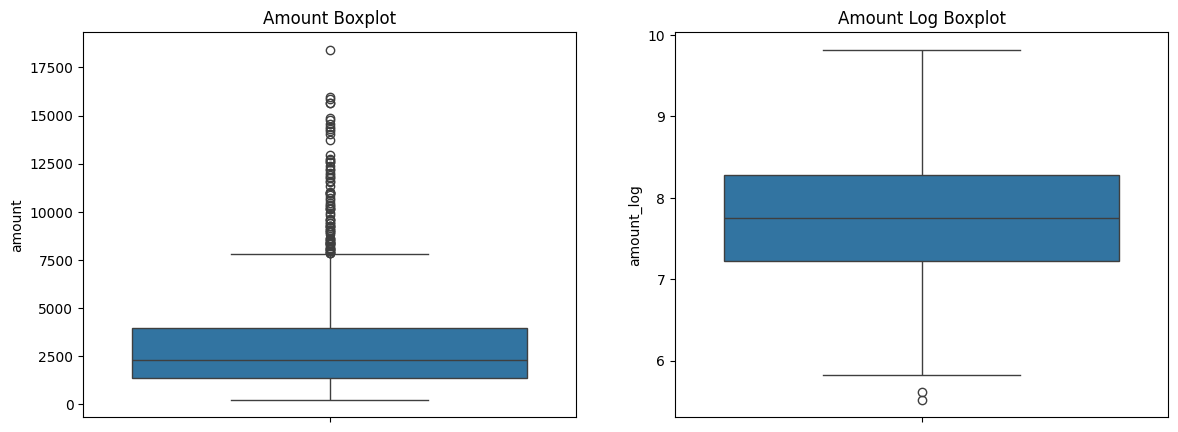

In [12]:
from scipy import stats
amount = df_credit['amount']

##Identifying outliers using IQR (Method - 1)

#Defining first quartile(25%)
Q1 = np.percentile(amount, 25)
#Defining third quartile(75%)
Q3 = np.percentile(amount, 75)
#IQR Range
IQR = Q3 - Q1

#Identifying outliers
outliers_IQR = amount[(amount < (Q1 - 1.5 * IQR)) | (amount > (Q3 + 1.5 * IQR))]

print(f"Outliers using IQR method : {len(outliers_IQR)}")

##Identifying outliers using Z-score (Method - 2)

#Calculating z-score
z_score = np.abs(stats.zscore(amount))
#Considering values with z-score > 3 as outliers
outliers_z_score = amount[np.abs(z_score) > 3]

print(f"Outliers using Z-score method : {len(outliers_z_score)}")

print(f"\nWe got less outliers using z-score method than IQR method")

#Handling the outliers using log transformation to ensure they do not skew my analysis
df_credit['amount_log'] = np.log(df_credit['amount'])

#Checking by plotting
print("\nChecking by plotting")
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.boxplot(df_credit['amount'])
plt.title('Amount Boxplot')
plt.subplot(1, 2, 2)
sns.boxplot(df_credit['amount_log'])
plt.title('Amount Log Boxplot')
plt.show()



3. The checking_balance column contains categorical data. How would you apply one-hot encoding to this column? What are the potential pitfalls of one-hot encoding, and how can you mitigate them?

**Observation**
*   For checking_balance column we can consider
    *   '0 DM' -> Low Balance
    *   '1 - 200 DM' -> Medium Balance
    *   '> 200 DM' -> High Balance
    *   'unknown' -> No checking Account








In [13]:
#Checking unique categories in checking_balance
print(f"Unique categories in checking_balance : {df_credit['checking_balance'].unique()}")

#Applying one-hot encoding
df_credit_encoded = pd.get_dummies(df_credit, columns=['checking_balance'],drop_first=True)

print(f"\nChecking the encoded data")
df_credit_encoded.head()


Unique categories in checking_balance : ['< 0 DM' '1 - 200 DM' 'unknown' '> 200 DM']

Checking the encoded data


,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default,amount_log,checking_balance_< 0 DM,checking_balance_> 200 DM,checking_balance_unknown
0,6.00,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67.00,none,own,2,skilled,1,yes,no,7.06,True,False,False
1,48.00,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22.00,none,own,1,skilled,1,no,yes,8.69,False,False,False
2,12.00,critical,education,2096,< 100 DM,4 - 7 years,2,3,49.00,none,own,1,unskilled,2,no,no,7.65,False,False,True
3,42.00,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45.00,none,other,1,skilled,2,no,no,8.97,True,False,False
4,18.00,poor,car,4870,< 100 DM,1 - 4 years,3,4,53.00,none,other,2,skilled,2,no,yes,8.49,True,False,False


Here One-hot encoding converts categorical variables into binary columns (0 or 1) which is (True or Flase), where each unique category becomes its own column.




**The potential pitfalls of one-hot encoding which we used here**
*   One-hot encoding creates linearly dependent columns (they sum to 1).This causes issues in models like Linear Regression due to multicollinearity.
> we can mitigate this using `drop_first=True` in `pd.get_dummies()` to drop one redundant column.
*   If the categorical column has many unique values, one-hot encoding creates too many columns.
> we can mitigate this by combining rare categories into one.



4. Perform a correlation analysis between the following variables: amount, months_loan_duration, percent_of_income, and age. Create a heatmap plot to visualize the correlation matrix. Additionally, create scatter plots for amount vs. each of the other variables. What insights can you draw from these visualizations?

Correlation Matrix:
                      amount  months_loan_duration  percent_of_income   age
amount                  1.00                  0.58              -0.27  0.03
months_loan_duration    0.58                  1.00               0.07 -0.05
percent_of_income      -0.27                  0.07               1.00  0.04
age                     0.03                 -0.05               0.04  1.00




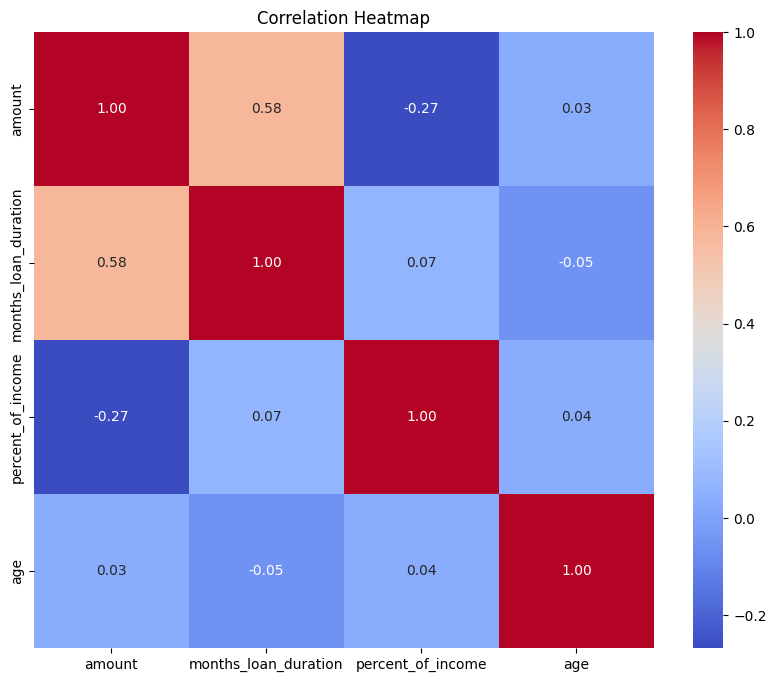

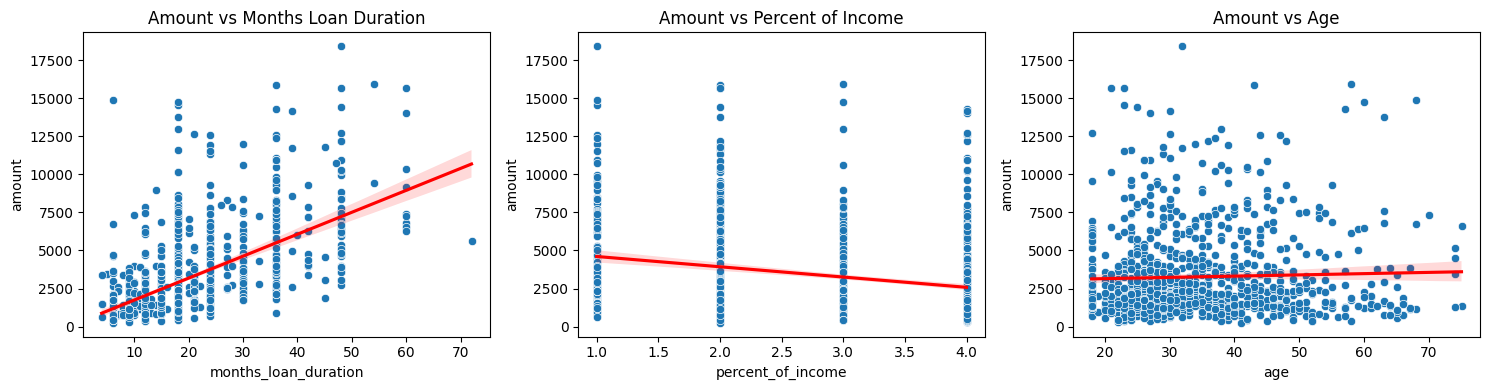

In [14]:
#Correlation analysis between the following variables: amount, months_loan_duration, percent_of_income, and age
selected_columns = ['amount', 'months_loan_duration', 'percent_of_income', 'age']
correlation_matrix = df_credit[selected_columns].corr()

print("Correlation Matrix:")
print(correlation_matrix)
print("\n")

#Displaying Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()
print("\n")

#Scatter plot for amount vs months_loan_duration
plt.figure(figsize=(15, 4))
plt.subplot(1,3,1)
sns.scatterplot(x='months_loan_duration', y='amount', data=df_credit)
sns.regplot(x='months_loan_duration', y='amount', data=df_credit, scatter=False, color='red')
plt.title('Amount vs Months Loan Duration')
print("\n")

#Scatter plot for amount vs percent_of_income
plt.subplot(1,3,2)
sns.scatterplot(x='percent_of_income', y='amount', data=df_credit)
sns.regplot(x='percent_of_income', y='amount', data=df_credit, scatter=False, color='red')
plt.title('Amount vs Percent of Income')
print("\n")

#Scatter plot for amount vs age
plt.subplot(1,3,3)
sns.scatterplot(x='age', y='amount', data=df_credit)
sns.regplot(x='age', y='amount', data=df_credit, scatter=False, color='red')
plt.title('Amount vs Age')
plt.tight_layout()
plt.show()

**Observation**
*   Heatmap:
    *   amount vs months_loan_duration -> Moderate Positive Correaltion
    *   amount vs percent_of_income -> Weak Negative Correaltion
    *   amount vs age -> No Correaltion
*   Scatter Plots:
    *   amount vs months_loan_duration -> Visible slightly upward trend (higher loan durations associated with higher amounts)
    *   amount vs percent_of_income -> Scattered, no clear pattern
    *   amount vs age -> No visible trend (spread across all ages)





5. Normalize the amount column using Min-Max scaling. Why is normalization important, and how does it affect the performance of machine learning models?

      amount  amount_scaled
373    13756           0.74
603     3349           0.17
602     1837           0.09
886     2825           0.14
536     1374           0.06
682     1478           0.07
1015    3069           0.16
440     1884           0.09
863     4526           0.24
919     3345           0.17


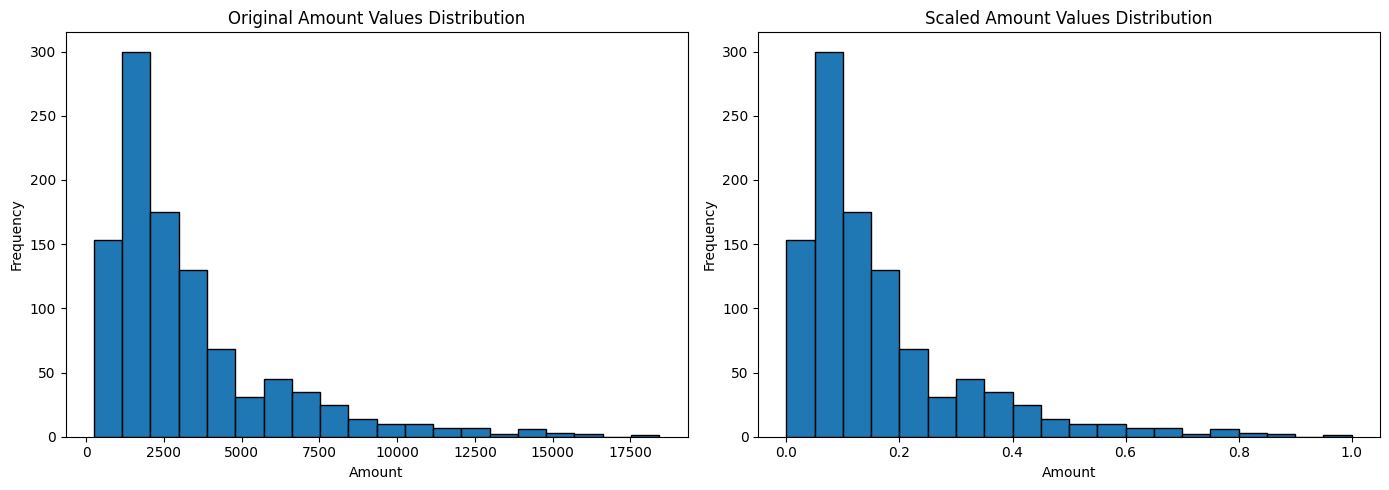

In [15]:
from sklearn.preprocessing import MinMaxScaler
##Normalizing the amount column using Min-Max scaling

#Intializing Scalar
scaler = MinMaxScaler()

#Fitting and transforming the data
df_credit['amount_scaled'] = scaler.fit_transform(df_credit[['amount']])

#Comparing original and scaled amount values
print(df_credit[['amount', 'amount_scaled']].sample(10))

#Visualizing original and scaled amount values
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.hist(df_credit['amount'], bins=20, edgecolor='black')
plt.title('Original Amount Values Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df_credit['amount_scaled'], bins=20, edgecolor='black')
plt.title('Scaled Amount Values Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


*   Normalization is important because:
    *   Normalization and scaling bring the different features to the same scale, allowing fair comparison and ensuring that no particular feature dominates other
*   It affect the performance of machine learning models by
    *   Improving accuracy and stability and reduceing training time
    *   Preventing feature dominance in models







6. Create a new feature called loan_to_income_ratio by dividing amount by percent_of_income. How can this new feature be useful in predicting loan default?

In [16]:
#Creating a new feature called loan_to_income_ratio by dividing amount by percent_of_income
df_credit['loan_to_income_ratio'] = df_credit['amount'] / df_credit['percent_of_income']

print(df_credit[['amount', 'percent_of_income', 'loan_to_income_ratio']].sample(10))

     amount  percent_of_income  loan_to_income_ratio
779    3872                  2               1936.00
910    4454                  4               1113.50
877    3595                  4                898.75
458     343                  4                 85.75
681    2279                  4                569.75
202    5117                  3               1705.67
371    6070                  3               2023.33
968    7166                  2               3583.00
603    3349                  4                837.25
211    3835                  2               1917.50


*   loan_to_income_ratio tells how large the loan is relative to the income contribution.
*   This new feature can be useful in predicting loan default by categorizing the ratio as:
    *   High ratio (means high risk) -> very high loan-to-income ratios are more likely to default.
    *   Low ratio (means low risk) -> Smaller ratios often indicate safer side.
>Adding this feature helps our ML model to capture financial stress levels, improving default prediction.





7. The employment_duration column has categorical values like > 7 years, 1 - 4 years, etc. How would you transform this column into numerical values suitable for machine learning algorithms?

In [17]:
#Checking the unique values in employment_duration column
df_credit['employment_duration'].unique()

array(['> 7 years', '1 - 4 years', '4 - 7 years', 'unemployed',
       '< 1 year'], dtype=object)

*   Since employment_duration reflects a natural order (more years = more stable
employment), we can map each category to a ranked number means we can can use **"Ordinal Encoding"**




In [18]:
#Making an ordinal mapping for employment_duration
ordinal_mapping = {
    'unemployed': 0,
    '< 1 year': 1,
    '1 - 4 years': 2,
    '4 - 7 years': 3,
    '> 7 years': 4
}

#Applying the ordinal mapping
df_credit['employment_duration_encoded'] = df_credit['employment_duration'].map(ordinal_mapping)

print(df_credit[['employment_duration', 'employment_duration_encoded']].sample(10))

    employment_duration  employment_duration_encoded
190         1 - 4 years                            2
736         1 - 4 years                            2
36          1 - 4 years                            2
338         1 - 4 years                            2
189         1 - 4 years                            2
933           > 7 years                            4
16            > 7 years                            4
269           > 7 years                            4
198           > 7 years                            4
516            < 1 year                            1


*   Machine learning models like Logistic Regression can now interpret this feature as increasing employment stability.
*   Preserves the ordinal relationship between categories (e.g., > 7 years is greater than 1 - 4 years).



8. The default column indicates whether a loan defaulted or not. If the dataset is imbalanced, what techniques can you use to handle this imbalance?

*   Here we are dealing with a classification problem which is predicting loan default (0 = no, 1 = yes), it's very common to have an imbalanced dataset in this — meaning, way more non-defaults than defaults.
*   This might create a problem because the model may predict the majority class (0 = no default) most of the time and still achieve high accuracy.
*   **Few Techniques to Handle Imbalanced Datasets:**
    *   Resampling
        *   Oversampling -> Increase the number of minority class samples by generating synthetic data.
        *   Undersampling -> Reduce the majority class by randomly removing samples.
    *   Using Class Weighting -> Assigning more importance to the minority class during training.









9. Bin the age column into categories such as young, middle-aged, and senior. How can binning improve the performance of certain machine learning models?

In [19]:
df_credit['age'].unique()

array([67., 22., 49., 45., 53., 35., 18., 25., 24., 60., 28., 32., 44.,
       31., 48., 26., 36., 39., 42., 34., 63., 37., 30., 58., 23., 27.,
       50., 61., 29., 46., 51., 41., 40., 66., 47., 52., 56., 54., 33.,
       20., 21., 38., 70., 65., 74., 68., 43., 55., 64., 57., 75., 19.,
       62., 59.])

In [20]:
#Defining bins and labels
bins = [0, 30, 50, 100]
labels = ['Young', 'Middle-Aged', 'Senior']

#Applying binning
df_credit['age_category'] = pd.cut(df_credit['age'], bins=bins, labels=labels, right=False)

print(df_credit[['age', 'age_category']].sample(10))

      age age_category
61  50.00       Senior
987 64.00       Senior
822 41.00  Middle-Aged
933 42.00  Middle-Aged
331 30.00  Middle-Aged
251 46.00  Middle-Aged
548 24.00        Young
606 74.00       Senior
580 30.00  Middle-Aged
327 34.00  Middle-Aged


*   Binning improve the performance of certain machine learning models by:
    *   Simplifing Patterns -> Converting noisy numerical data into high-level trends
    *   Handling Non-linearity -> Capturing non-linear relationships more easily
    *   Reducing Overfitting -> Fewer categories = fewer chances to memorize noise





10. Split the dataset into training and testing sets. What considerations should you consider when splitting the data? How would you ensure that the split is representative of the overall dataset?

Shape of X_train : (819, 21)
Shape of X_test : (205, 21)

Distribution of target class in y_train : default
no     572
yes    247
Name: count, dtype: int64
Distribution of target class in y_test : default
no     143
yes     62
Name: count, dtype: int64
Total distribution of target class in y : default
no     715
yes    309
Name: count, dtype: int64




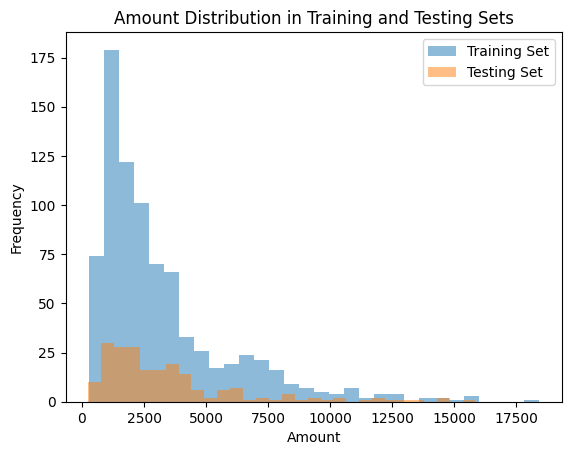

In [21]:
from sklearn.model_selection import train_test_split
#Spliting the dataset into training and testing sets

#defining features and target variables
X = df_credit.drop(columns=['default'])
y = df_credit['default']

#Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

#Display the shape
print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of X_test : {X_test.shape}")

#Check distribution of target class
print(f"\nDistribution of target class in y_train : {y_train.value_counts()}")
print(f"Distribution of target class in y_test : {y_test.value_counts()}")
print(f"Total distribution of target class in y : {y.value_counts()}")
print("\n")

#Visualizing with histogram
plt.hist(X_train['amount'],bins=30,alpha=0.5,label='Training Set')
plt.hist(X_test['amount'],bins=30,alpha=0.5,label='Testing Set')
plt.legend()
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.title('Amount Distribution in Training and Testing Sets')
plt.show()


**Considerations we are considering when splitting the data:**
*   Ensuring that the class distribution (e.g., default vs. non-default) is similar in both train and test sets by using `stratify=y`.
*   Using a `random_state` for reproducibility.
*   Typical splits should be 80/20.
*   Shuffling which helps prevent order bias (default behavior in `train_test_split`).




**We ensure that the split is representative of the overall dataset by seeing:**
*   The distribution of target variable are very similar for train, test and total so our split is representative
    *   Training set ->
      * no_pecentage (572/572+247) = (572/819) = 0.698 = 69.8%  
      * yes_pecentage (247/572+247) = (247/819) = 0.302 = 30.2%    
    *   Testing set ->
      * no_pecentage (143/143+62) = (143/205) = 0.6976 = 69.76%  
      * yes_pecentage (62/143+62) = (62/205) = 0.3024 = 30.24%
    *   Total set ->
      * no_pecentage (715/715+309) = (715/1024) = 0.6982 = 69.82%  
      * yes_pecentage (309/715+309) = (309/1024) = 0.3017 = 30.17%


*   The histogram also confirms that the training and test sets follow a similar distribution, ensuring the split is representative of the overall dataset.



11. Check for duplicates in the dataset. If there are duplicates, drop them from the dataset.

In [22]:
#Checking for duplicates
print(f"Number of duplicates in the dataset : {df_credit.duplicated().sum()}")

#Dropping duplicates
if df_credit.duplicated().sum() > 0:
    df_credit.drop_duplicates(inplace=True)
    print(f"\nNumber of duplicates after dropping : {df_credit.duplicated().sum()}")
    print("Duplicates dropped successfully.")
else:
    print("No duplicates found in the dataset.")



Number of duplicates in the dataset : 24

Number of duplicates after dropping : 0
Duplicates dropped successfully.
